# RAG with LlamaIndex - Retrieving and Generating


After setting up the data connectors and indexes, we will move on to the retrieval and generation process. Let's see how the end-to-end LlamaIndex RAG pipeline looks like.

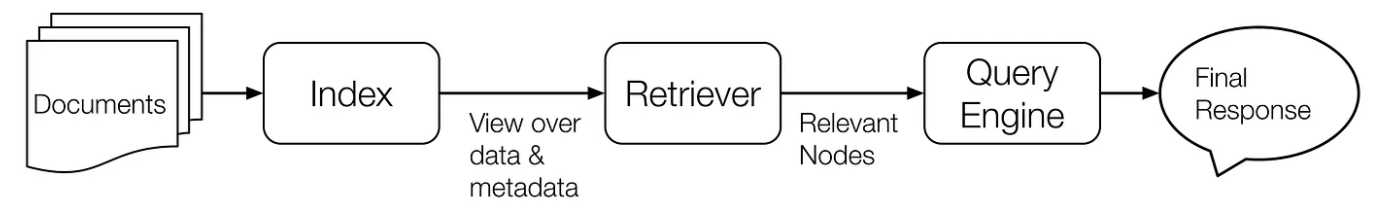

In [4]:
# %pip install -q llama-index

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# You can also install the components separately like this
# %pip install -q llama-index-core llama-index-readers-file llama-index-embeddings-huggingface llama-index-embeddings-openai llama-index-llms-openai llama-index-llms-huggingface-api llama-index-vector-stores-chroma llama-index-vector-stores-faiss chromadb faiss-cpu

Note: you may need to restart the kernel to use updated packages.


### Load the documents

In [1]:
from llama_index.readers.file import PDFReader

loader = PDFReader()
documents = loader.load_data(file = 'data/uber_2022.pdf')
print(f"Loaded {len(documents)} docs")

Loaded 149 docs


### Transformations

A [transformation](https://developers.llamaindex.ai/python/framework/module_guides/loading/ingestion_pipeline/transformations/) takes in a list of nodes or documents, performs some operation on it, and returns a list of nodes

The following components are Transformation objects:
- `TextSplitter`
- `NodeParser`
- `MetadataExtractor`
- `Embeddings` model

In [2]:
from llama_index.core.node_parser import SentenceSplitter

node_parser = SentenceSplitter(chunk_size=512, chunk_overlap=50)

# use transforms directly (what we have been doing)
nodes = node_parser(documents)

The usefulness of transformations is that they can be passed into an index or overall global settings, and will be used when calling `from_documents()` or `insert()` on an index.

In [3]:
from llama_index.core import VectorStoreIndex

transformations = [
    node_parser,        # list of transformations (chunking, embedding etc.)
]

# Adding transformations per-index
index = VectorStoreIndex.from_documents(
    documents, transformations=transformations
)

2026-03-27 01:20:33,325 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-03-27 01:20:36,375 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-03-27 01:20:37,294 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-03-27 01:20:38,214 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


In [ ]:
# Applying global settings so the transforms run by default
from llama_index.core import Settings

# Settings.transformations = transformations

You can also create [custom transformations](https://developers.llamaindex.ai/python/framework/module_guides/loading/ingestion_pipeline/transformations/#custom-transformations).


So, transformations are quite useful while defining RAG pipelines. However, these are best used with an ingestion pipeline.

### Ingestion Pipeline

An [`IngestionPipeline`](https://developers.llamaindex.ai/python/framework/module_guides/loading/ingestion_pipeline/) uses Transformations that are applied to input data, and the resulting nodes are either returned or inserted into a vector database (if given)

Ingestion Pipelines are structured workflows that manage the entire process of loading, transforming, and storing data, often including caching. Whereas Transformations are the individual, granular processing steps (e.g., chunking, embedding) applied to nodes within that pipeline or individually.

A simple ingestion pipeline is just the transformations to perform

In [ ]:
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
embedder = HuggingFaceEmbedding(model_name="all-MiniLM-L6-v2")

In [41]:
from llama_index.core import Document
from llama_index.core.ingestion import IngestionPipeline, IngestionCache

# create the pipeline with transformations
pipeline = IngestionPipeline(
    name = "pipe1",
    transformations=[
        node_parser, embedder
    ]
)

# run the pipeline (we're using an example doc here)
nodes = pipeline.run(documents=[Document.example()])

Let's see what the node looks like

In [42]:
nodes

[TextNode(id_='84870bb8-f7dc-4cf5-9377-70d9b9ab3fc4', embedding=[-0.022512352094054222, -0.046268753707408905, -0.07496222853660583, 0.03027360700070858, 0.019600093364715576, -0.02831571362912655, 0.0054830145090818405, 0.04624713584780693, -0.0717373862862587, 0.04747956246137619, -0.0072233062237501144, -0.0035070092417299747, 0.09748424589633942, -0.00597308948636055, 0.04078542813658714, 0.09907601773738861, 0.012469975277781487, 0.0068087805993855, 0.011238216422498226, -0.020687630400061607, 0.005979711189866066, 0.054794181138277054, 0.012912658974528313, -0.04514147713780403, 0.01894754357635975, 0.08691101521253586, 0.03769717365503311, 0.0035794642753899097, -0.005894357338547707, -0.025963133201003075, 0.047298017889261246, 0.0643957108259201, -0.007295377552509308, 0.07909513264894485, -0.03424276411533356, 0.016226258128881454, 0.04688281565904617, 0.007274792529642582, -0.11580219864845276, -0.031428102403879166, -0.008627418428659439, 0.023836228996515274, -0.0135857649

And here we have the embeddings with nodes as well! Without the pipeline, we did not have a way to do so without some extra effort. See how transfoms and pipelines make the various stages so much easier.

A pipeline can also be combined with a vector store. When running an ingestion pipeline, you can also chose to automatically insert the resulting nodes into a remote vector store.

Then, you can construct an index from that vector store later on

Note that if you are connecting your pipeline to a vector store, embeddings must be a stage of your pipeline or your later instantiation of the index will fail.

In [52]:
from llama_index.core import Document
import chromadb
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.core import StorageContext

chroma_client = chromadb.PersistentClient(path="./chroma_llamaindex_db")

chroma_collection = chroma_client.get_or_create_collection("chroma_vectorstore")
chroma_vector_store = ChromaVectorStore(chroma_collection=chroma_collection)

pipeline = IngestionPipeline(
    name="pipeline",
    transformations=[
        node_parser, embedder
    ],
    vector_store=chroma_vector_store
)

In [53]:
# Run the pipeline to ingest directly into a vector db
pipeline.run(documents=documents)   # pass docs as keyword as the first argument is show_progress

[TextNode(id_='64ff3fb2-9719-4b09-ba8d-de51309f565d', embedding=[-0.04267936944961548, 0.007516880519688129, -0.03444283828139305, -0.054149724543094635, -0.05696649104356766, 0.04684334620833397, 0.006213066168129444, 0.040406860411167145, -0.05377354472875595, 0.028432976454496384, 0.06860852986574173, 0.03361960127949715, 0.005253409501165152, -0.041502293199300766, -0.019681986421346664, 0.09221851080656052, 0.002592342672869563, -0.037534866482019424, -0.0030594817362725735, 0.022549498826265335, 0.06335486471652985, -0.02767876908183098, -0.05164504796266556, -0.02669917605817318, 0.04330185428261757, -0.008207389153540134, -0.05923115462064743, 0.024419987574219704, -0.06456505507230759, -0.010788287036120892, -0.017624245956540108, 0.053680725395679474, -0.023804796859622, 0.018439175561070442, 0.10546263307332993, -0.0584726519882679, 0.005354778375476599, -0.0038316850550472736, 0.06898870319128036, -0.0963054671883583, 0.04795197769999504, -0.06889160722494125, -0.0358766913

When you run an ingestion pipeline with a vector store, the pipeline processes documents and inserts the resulting nodes directly into the vector store.

However, the pipeline itself does not create a queryable index object; it only handles data ingestion and storage. To perform retrieval or querying, we must create a `VectorStoreIndex` that wraps the vector store.

In [ ]:
chroma_collection.count()   # check before creating the index

388

In [55]:
# Create index
from llama_index.core import VectorStoreIndex

index = VectorStoreIndex.from_vector_store(chroma_vector_store)

Remember, we used MiniLM embeddings. We will need to make it the default setting so that other components also use the correct embeddings.

In [48]:
Settings.embed_model = embedder

---

## Querying

Now you’ve loaded your data, built an index, and stored that index for later, you’re ready to get to the most significant part, querying

In LlamaIndex, querying consists of mostly three parts
- Retrieval, when you find and return the most relevant documents for your query from your Index
- Postprocessing, when the Nodes retrieved are optionally reranked, transformed, or filtered
- Response synthesis, when your query, your most-relevant data and your prompt are combined and sent to your LLM to return a response

All of these combined form a **query engine**

### Retrieval


A **Retriever** is the component that takes a query, embeds it, and finds the most similar Nodes from the index. It returns `NodeWithScore` objects - each containing the Node's text, metadata, and a **similarity score** indicating how closely the Node's meaning matches the query.


The similarity score typically ranges from 0 to 1 (for cosine similarity), where:
- **1.0** means the node's meaning is identical to the query
- **0.7-0.9** indicates strong relevance
- **Below 0.5** generally indicates weak or no relevance

The key parameter is **`similarity_top_k`** - the number of Nodes the retriever returns. This parameter directly controls the trade-off between recall (finding all relevant information) and precision (avoiding irrelevant noise).

A simple way of using a retriever is

In [63]:
retriever = index.as_retriever(similarity_top_k=3)
retriever.retrieve("What was uber's revenue in 2021?")

[NodeWithScore(node=TextNode(id_='be825ef1-c4a6-4691-9cf0-2a2ff3d6aa88', embedding=None, metadata={'page_label': '55', 'file_name': 'uber_2022.pdf'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='5c6b2911-b7cc-4ebe-9d44-b2022ae294a2', node_type='4', metadata={'page_label': '55', 'file_name': 'uber_2022.pdf'}, hash='da53fa8e0c51bec1f5112679b03510b879adff3cfeac782dcd4eb9c5c83a90cc'), <NodeRelationship.PREVIOUS: '2'>: RelatedNodeInfo(node_id='6e51b460-fdc8-46c8-bdb1-d7717cbe27bd', node_type='1', metadata={'page_label': '55', 'file_name': 'uber_2022.pdf'}, hash='e8ec6aa317c8e9bf4fc604158f6784d099a0960a2e1c0b3bb64226d53a22051f')}, metadata_template='{key}: {value}', metadata_separator='\n', text='Additionally, we saw a $3.9 billion net increase in Mobility revenue as a result of business \nmodel changes in the UK and accruals made for the resolution of historical claims in the UK relating to the classi

The `.as_retriever()` method in itself is an abstraction of the `VectorStoreRetriever()` class. Use this class to configure a retriever with finer controls.

Let's try using top-k nodes based on hybrid retrieval

In [160]:
from llama_index.core.retrievers import VectorIndexRetriever

retriever = VectorIndexRetriever(
    index=index,
    similarity_top_k=10,
    # hybrid_top_k=5,
)

In [161]:
retriever.retrieve("What information do you have about the mobility service of uber??")

[NodeWithScore(node=TextNode(id_='f4ec4040-c6b4-400d-933a-472947bb97f6', embedding=None, metadata={'page_label': '12', 'file_name': 'uber_2022.pdf'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='2e13801f-dca4-46da-a969-44228ef7b20a', node_type='4', metadata={'page_label': '12', 'file_name': 'uber_2022.pdf'}, hash='0b0327c9fcc8f0e578de28533d2964d1f936e1d6a82566c211396bab7c899735'), <NodeRelationship.PREVIOUS: '2'>: RelatedNodeInfo(node_id='047dc3ef-361b-4568-917b-30da8c210e35', node_type='1', metadata={'page_label': '12', 'file_name': 'uber_2022.pdf'}, hash='bfe6e8bbd97bbe86dbfdd8d18aa02ea439a068fdff0442fabf54d1c57f94230f'), <NodeRelationship.NEXT: '3'>: RelatedNodeInfo(node_id='7512e538-cafa-4aa1-a400-06313f7668cf', node_type='1', metadata={}, hash='fe29143d8910eb1fd35675ec9680448386e757f4546a4cdb7a1c30972fdb697d')}, metadata_template='{key}: {value}', metadata_separator='\n', text='In markets ac

You can also define metadata filters while creating the retriever

In [162]:
from llama_index.core.vector_stores import MetadataFilters, MetadataFilter, FilterOperator

# Create a list of MetadataFilter objects
# containing metadata key, and value + operator for filtering

filter_list = [
        MetadataFilter(key="page_label", value="51", operator=FilterOperator.EQ),   # page equal to 51
        MetadataFilter(key="file_name", value="uber_2022.pdf", operator=FilterOperator.EQ),    # file name
    ]

# Add the list of MetadataFilter objects as a MetadataFilters object
filters = MetadataFilters(filters= filter_list)

# Add the MetadataFilters as filters
retriever_compound = index.as_retriever(
    similarity_top_k=3,
    filters=filters
)

In [163]:
retriever_compound.retrieve("revenue")

[NodeWithScore(node=TextNode(id_='ef69bcac-9c57-437a-a7a8-bfbd4c551ef6', embedding=None, metadata={'page_label': '51', 'file_name': 'uber_2022.pdf'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='78dd3619-d289-425f-9520-a49397deccde', node_type='4', metadata={'page_label': '51', 'file_name': 'uber_2022.pdf'}, hash='a981cd44beb69855dfc91e628986a19116bdbba49eb7e25930bdbbb39239126d'), <NodeRelationship.NEXT: '3'>: RelatedNodeInfo(node_id='e8e590b5-ab95-48e1-ad2a-2889cee3f03b', node_type='1', metadata={}, hash='ef864520ab507196a50a910118d02b11bea7ca23d4f958823afea6dbd8b62e6c')}, metadata_template='{key}: {value}', metadata_separator='\n', text='Financial and Operational Highlights\nYear Ended December 31, Constant Currency (1)\n(In millions, except percentages) 2021 2022\n2021 to 2022 \n% Change\n2021 to 2022 % \nChange\nMonthly Active Platform Consumers (“MAPCs”) (2), (3) 118 131  11 %\nTrips (2) 6,3

Refer to [retriever usage, and retriever modes and modules references](https://developers.llamaindex.ai/python/framework/module_guides/querying/retriever/). You can also create more advanced retrievers like BM25 hybrid or custom ones.

### Postprocessing

**Node Postprocessors** are modules which apply some kind of transformation or filtering on retrieved nodes before returning them.

[Node postprocessors](https://developers.llamaindex.ai/python/framework/module_guides/querying/node_postprocessors/) are usually applied for tasks like reranking or filtering, in between the retrieval and response synthesis steps

In [197]:
from llama_index.core.postprocessor import SimilarityPostprocessor
from llama_index.core.postprocessor import SentenceTransformerRerank

# retrieval
result = retriever.retrieve("uber's revenue in 2021")

# similarity postprocessor: filter nodes below 0.5 similarity score
processor = SimilarityPostprocessor(similarity_cutoff=0.5)
filtered_nodes = processor.postprocess_nodes(result)

# rerank nodes given query using trained model
reranker = SentenceTransformerRerank(top_n=5)
reranked = reranker.postprocess_nodes(result, query_str="uber's revenue in 2021")

2026-03-27 05:36:40,296 - INFO - HTTP Request: HEAD https://huggingface.co/cross-encoder/stsb-distilroberta-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-27 05:36:40,569 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/stsb-distilroberta-base/6b71347df6e2b34246b53e06d6bce70ef67de368/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/stsb-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-27 05:36:40,985 - INFO - HTTP Request: HEAD https://huggingface.co/cross-encoder/stsb-distilroberta-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-27 05:36:41,260 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/stsb-distilroberta-base/6b71347df6e2b34246b53e06d6bce70ef67de368/config.json "HTTP/1.1 200 OK"
2026-03-27 05:36:41,576 - INFO - HTTP Request: HEAD https://huggingface.co/cross-encoder/stsb-distilroberta-base/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-27 05:36:41,870 - INFO - HTTP Request: HEAD https://huggingface.co

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [198]:
reranked

[NodeWithScore(node=TextNode(id_='8f2a56a5-8af8-4bd3-8473-4b7f798f125a', embedding=None, metadata={'page_label': '93', 'file_name': 'uber_2022.pdf'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='e8acd72f-39b1-46db-82ed-7bff3c224b24', node_type='4', metadata={'page_label': '93', 'file_name': 'uber_2022.pdf'}, hash='1acf54e83d28963b48bbe47c33fd228e9fd9f7d27334f596817d50a722cf3733'), <NodeRelationship.PREVIOUS: '2'>: RelatedNodeInfo(node_id='946afdf2-49ee-479f-80a2-e906e82896ca', node_type='1', metadata={'page_label': '93', 'file_name': 'uber_2022.pdf'}, hash='5a90332b361625aaa309981120609687be16ac6ae46f7a5eb6c7a0ebbfaae2a2')}, metadata_template='{key}: {value}', metadata_separator='\n', text='Also included is the cost of customer support, Driver background checks and the \nallocation of certain corporate costs.\n• Sales and marketing expenses primarily consist of compensation costs, including stock

Node postprocessors are generally used within the query engine

### Response Synthesizers

[Response synthesizer](https://developers.llamaindex.ai/python/framework/module_guides/querying/response_synthesizers/) is the augmentation + generation step of pipeline. It uses a query and given set of chunks to generate a response from an LLM.

#### Response Modes

The `response_mode` parameter controls **how** the LLM synthesises its answer from the retrieved Nodes. Different modes suit different use cases:

| Mode | How It Works | Best For |
|---|---|---|
| `COMPACT` **(default)** | Stuffs as many nodes as possible into a single prompt (one LLM call); if they exceed the limit, they are merged first | Most queries - good balance of speed and quality |
| `REFINE` | Processes nodes one at a time (separate LLM calls), iteratively refining the answer with each | Complex questions requiring synthesis across many sources |
| `TREE_SUMMARIZE` | Recursively summarises pairs of nodes into a final answer | Summarising large amounts of retrieved content |
| `SIMPLE_SUMMARIZE` | Truncates all nodes to fit in one prompt | Quick, low-cost answers |
| `ACCUMULATE` | Generates a separate answer from each node, then concatenates | When per-source answers are needed |
| `NO_TEXT` | Returns only the retrieved nodes, no LLM generation | Retrieval-only use cases (debugging, evaluation) |

We can create a response synthesizer using `get_response_synthesizer()` function. We can also define the response mode with it.

In [199]:
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
from llama_index.core import get_response_synthesizer
from llama_index.core.response_synthesizers import ResponseMode

llm = HuggingFaceInferenceAPI(model_name="Qwen/Qwen2.5-7B-Instruct",max_tokens=512)

# or just declare gloablly
# Settings.llm = HuggingFaceInferenceAPI(model_name="Qwen/Qwen2.5-7B-Instruct",max_tokens=512)

# Create
response_synthesizer = get_response_synthesizer(
    llm = llm,
    response_mode=ResponseMode.COMPACT
)

In [200]:
# Use the reranked chunks and query to pass for augmentation and get answer
response = response_synthesizer.synthesize(nodes=reranked, query="uber's revenue in 2021")

2026-03-27 05:36:55,229 - INFO - HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 200 OK"


In [201]:
response

Response(response="Uber's revenue in 2021 was $17,455 million.", source_nodes=[NodeWithScore(node=TextNode(id_='8f2a56a5-8af8-4bd3-8473-4b7f798f125a', embedding=None, metadata={'page_label': '93', 'file_name': 'uber_2022.pdf'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='e8acd72f-39b1-46db-82ed-7bff3c224b24', node_type='4', metadata={'page_label': '93', 'file_name': 'uber_2022.pdf'}, hash='1acf54e83d28963b48bbe47c33fd228e9fd9f7d27334f596817d50a722cf3733'), <NodeRelationship.PREVIOUS: '2'>: RelatedNodeInfo(node_id='946afdf2-49ee-479f-80a2-e906e82896ca', node_type='1', metadata={'page_label': '93', 'file_name': 'uber_2022.pdf'}, hash='5a90332b361625aaa309981120609687be16ac6ae46f7a5eb6c7a0ebbfaae2a2')}, metadata_template='{key}: {value}', metadata_separator='\n', text='Also included is the cost of customer support, Driver background checks and the \nallocation of certain corporate costs.\n• Sales a

As you can see, the `Response` object is simply a combination of `response` and `NodeWithScore` object (which itself is a combination of `TextNode` and `score`)

The different response modes are useful in for various use cases. For instance, if you want to only see what chunks are being retrieved, without generating an LLM response, you can use `NO_TEXT`

In [202]:
response_retrieved = get_response_synthesizer(
    llm = llm,
    response_mode=ResponseMode.NO_TEXT
)

Response synthesizers are used after retriever and node postprocessors.

### Query Engine: Context Injection and Response Synthesis

A [**Query Engine**](https://developers.llamaindex.ai/python/framework/module_guides/deploying/query_engine/) is LlamaIndex's abstraction that combines retrieval and generation into a single interface

When a query is submitted to a query engine, it:
1. Retrieves the most relevant Nodes from the index (and processes them)
2. Injects those Nodes (along with their metadata) into a prompt
3. Sends the augmented prompt to the LLM
4. Returns the generated response along with the source Nodes used

We build the `QueryEngine` on an index as well, just like a retriever. In fact it calls `index.as_retriever(**kwargs)` to get the retriever and then wraps it in a `RetrieverQueryEngine`.


We can also use some `**kwargs` which are used in the components of query engine (arguments from retrievers or response synthesizers)

In [203]:
query_engine = index.as_query_engine(
    llm = llm,
    similarity_top_k=5,
    # hybrid_top_k = 5,
    response_mode="compact")
response = query_engine.query("uber's revenue in 2021")

2026-03-27 05:37:05,771 - INFO - HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 200 OK"


In [ ]:
response.response

You can also use streaming responses

In [ ]:
# another example
query_engine = index.as_query_engine(
    llm = llm,
    similarity_top_k=5,
    sparse_top_k=5,
    response_mode="tree_summarize",
    # and, also stream responses
    streaming=True
    )

query = "What information do you have about the mobility service of uber?"
query_engine.query(query).print_response_stream()

2026-03-27 05:38:48,784 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Uber's Mobility service connects consumers with various transportation options such as ridesharing, carsharing, micromobility, rentals, public transit, taxis, and more. The company believes that its global leadership position and extensive marketplace data allow it to innovate quickly compared to competitors with similar products. Additionally, Uber's Mobility segment aims to offer consumers better experiences with different vehicle types, ensuring higher reliability and providing drivers with improved earnings opportunities. The Mobility service also includes activities related to financial partnerships products and advertising.

While discussing retrievers, postprocessors, and synthesizers, we discussed at what step in the final query engine pipeline they fit. Let's see how we can explicitly use these components in a query engine.


In [211]:
from llama_index.core.query_engine import RetrieverQueryEngine

query_engine = RetrieverQueryEngine(
    retriever=retriever,
    node_postprocessors=[processor, reranker],
    response_synthesizer=response_synthesizer
)

In [213]:
query_engine.query('uber revenue in 2021')

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-03-27 05:40:23,811 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Response(response='$17,455 million', source_nodes=[NodeWithScore(node=TextNode(id_='8f2a56a5-8af8-4bd3-8473-4b7f798f125a', embedding=None, metadata={'page_label': '93', 'file_name': 'uber_2022.pdf'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='e8acd72f-39b1-46db-82ed-7bff3c224b24', node_type='4', metadata={'page_label': '93', 'file_name': 'uber_2022.pdf'}, hash='1acf54e83d28963b48bbe47c33fd228e9fd9f7d27334f596817d50a722cf3733'), <NodeRelationship.PREVIOUS: '2'>: RelatedNodeInfo(node_id='946afdf2-49ee-479f-80a2-e906e82896ca', node_type='1', metadata={'page_label': '93', 'file_name': 'uber_2022.pdf'}, hash='5a90332b361625aaa309981120609687be16ac6ae46f7a5eb6c7a0ebbfaae2a2')}, metadata_template='{key}: {value}', metadata_separator='\n', text='Also included is the cost of customer support, Driver background checks and the \nallocation of certain corporate costs.\n• Sales and marketing expenses primar

## Custom Prompt Templates

The default prompts LlamaIndex uses internally can be overridden. This is useful when the application requires a specific answer format, tone, or grounding behaviour (e.g., "cite every claim" or "respond only in bullet points").

In [ ]:
from llama_index.core import PromptTemplate

custom_qa_prompt = PromptTemplate(
    """You are a financial analyst assistant. Use ONLY the context below to answer.
If the context does not contain the answer, say "Insufficient information in the provided documents."
Cite the source document for each claim.

Context:
{context_str}

Question: {query_str}

Provide a concise, well-structured answer:"""
)


custom_engine = index.as_query_engine(
    llm=llm
    similarity_top_k=4,
    text_qa_template=custom_qa_prompt
)

response = custom_engine.query("Which services gave uber the most revenue?")

2026-03-27 05:47:23,237 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [ ]:
# or, to use the predefined querying components
# define the response synthesizer again with the text_qa_template

response_synthesizer = get_response_synthesizer(
    # llm=llm,
    text_qa_template=custom_qa_prompt
)

query_engine = RetrieverQueryEngine(
    retriever=retriever,
    node_postprocessors=[processor, reranker],
    response_synthesizer=response_synthesizer
)

In [216]:
response.response

"Uber generated the most revenue from its Mobility services, which primarily includes fees paid by Mobility Drivers for the use of the platform and related services, as well as revenue from fees paid by end-users for connection services obtained via the platform. This is evident from the significant increase in revenue from Mobility services over the years, as shown in the financial highlights section of the document. Additionally, revenue from Delivery services, which includes revenue from Merchants' and Couriers' use of the Delivery platform, also contributed to the overall revenue of the company.\n\nSource: uber_2022.pdf, page_label: 96"

## Updating the Index: Adding New Documents



In a real-world application, the knowledge base is not static. New reports are published, new products are launched, and new policies are enacted. The RAG system must be able to **incorporate new documents** without rebuilding the entire index from scratch.


LlamaIndex supports incremental updates through the `insert()` method, which adds new Documents (parsed into Nodes, embedded, and indexed) to an existing index.

In [224]:
query_before = "What are the 2026 Q1 results?"
response_before = index.as_query_engine(llm=llm, similarity_top_k=10).query(query_before)

print("BEFORE adding new document:")
print(f"Q: {query_before}")
print(f"A: {response_before}")
print()

2026-03-27 05:57:53,133 - INFO - HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-27 05:57:54,488 - INFO - HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-27 05:57:55,922 - INFO - HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 200 OK"


BEFORE adding new document:
Q: What are the 2026 Q1 results?
A: The 2026 Q1 results show that revenue reached $10.35 billion, marking a 21% increase from the same period in the previous year and exceeding analyst expectations. The mobility services segment grew by 31% and now represents 68% of total revenue. The company also gained 840 new enterprise customers, bringing the total to 20,850. The operating margin remained steady at 22%, consistent with the Q4 2025 results. Free cash flow for Q1 2025 was reported as $3.32 billion.



In [225]:
from llama_index.core import Document

new_document = Document(
    text="""Uber - Q1 2026 Financial Results

First quarter 2026 revenue reached $10.35 billion, a 21% increase year-over-year and
ahead of analyst expectations. The mobility services segment continued its strong momentum,
growing 31% to represent 68% of total revenue.

Operating margin held steady at 22%, consistent with Q4 2025. The company added 840 new
enterprise customers during the quarter, bringing the total to 20,850. Free cash flow
for Q1 2025 was $3.32 billion.
""",
    metadata={
        "file_name": "q1_2026_results.txt",
        "department": "finance",
        "doc_type": "report",
        "year": 2026
    }
)

index.insert(new_document)

In [226]:
response_after = index.as_query_engine(llm=llm, similarity_top_k=3).query(query_before)

print("AFTER adding new document:")
print(f"Q: {query_before}")
print(f"A: {response_after}\n")

print("Sources used:")
for node in response_after.source_nodes:
    print(f"  - {node.node.metadata.get('file_name', 'unknown')} (score: {node.score:.4f})")

2026-03-27 05:57:57,462 - INFO - HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 200 OK"


AFTER adding new document:
Q: What are the 2026 Q1 results?
A: In the first quarter of 2026, Uber achieved a revenue of $10.35 billion, marking a 21% increase from the same period in the previous year and exceeding analyst expectations. The mobility services segment saw a significant growth of 31%, contributing to 68% of the total revenue. The operating margin remained stable at 22%, aligning with the fourth quarter of 2025. Additionally, Uber gained 840 new enterprise customers, bringing the total to 20,850. The free cash flow for the quarter was reported at $3.32 billion.

Sources used:
  - q1_2026_results.txt (score: 0.3537)
  - q1_2025_results.txt (score: 0.3420)
  - uber_2022.pdf (score: 0.2940)


The output above demonstrates the power of incremental updates. Before the new document was inserted, the system could not answer the Q1 2026 question (it would respond with general or irrelevant information). After insertion, the system retrieves the new document and produces an accurate, grounded answer.